# Round 1 Initial Product Analysis

This notebook performs an initial exploratory analysis for the two Round 1 products.

Goals:
1. Load and combine all price/trade files
2. Separate the two products
3. Analyze price behavior for each product
4. Look for structure, stationarity, mean reversion, jumps, and predictive signals
5. Build intuition for possible trading strategies


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12,5)

def round1_data_dir() -> Path:
    cwd = Path.cwd()
    for base in (cwd, cwd.parent):
        p = base / "data" / "ROUND1"
        if p.is_dir():
            return p
    raise FileNotFoundError(
        f"找不到 data/ROUND1，当前工作目录: {cwd.resolve()}。"
        "请从 88-Pineapple 仓库根目录启动内核，或在笔记本里 os.chdir 到仓库根。"
    )

DATA = round1_data_dir()
price_files = [DATA / f"prices_round_1_day_{d}.csv" for d in (-2, -1, 0)]
trade_files = [DATA / f"trades_round_1_day_{d}.csv" for d in (-2, -1, 0)]

prices = pd.concat([pd.read_csv(f, sep=";") for f in price_files], ignore_index=True)
trades = pd.concat([pd.read_csv(f, sep=";") for f in trade_files], ignore_index=True)

print(prices.columns)
print(trades.columns)
print(prices["product"].unique())


Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')
Index(['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price',
       'quantity'],
      dtype='object')
['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']


### Purpose
- Identify the exact Round 1 products present in the dataset.
- Split both price data and trade data into per-product dataframes for downstream analysis.

### Expected Result
- We should end up with one clean price dataframe and one clean trade dataframe for each product.
- All later sections should be able to refer to products directly by name.

### Intuition
- Most later diagnostics are product-specific, so the notebook should organize data around the true product identities from the start.
- This also prevents accidental mixing of price and trade records across products.

### Steps
1. Confirm the two product names in the raw files.
2. Build product-keyed dictionaries for prices and trades.
3. Expose direct variables for the two products for easier reference.


# 1. Split by Product

The two Round 1 products in this dataset are:
- `INTARIAN_PEPPER_ROOT`
- `ASH_COATED_OSMIUM`

We split both the price data and trade data by these exact product names.


### Purpose
- Build the core price features used throughout the notebook.
- Create a consistent `mid`, `spread`, and return series for both products.

### Expected Result
- Each product dataframe should contain a usable `mid`, `spread`, and `ret` column.
- Missing best bid or best ask quotes should not break the main price series.

### Intuition
- The raw files already include `mid_price`, which is safer than recomputing from top-of-book quotes when one side is missing.
- Returns and spread are the minimum ingredients needed to study flatness, drift, mean reversion, and microstructure behavior.

### Steps
1. Sort each product by `day` and `timestamp`.
2. Use `mid_price` as the main mid series, with bid/ask fallback only if needed.
3. Build `spread`, `ret`, and a monotonic time index for later diagnostics.


In [50]:
# 按产品名保存为不同 dataframe，后续可直接用产品名索引。
price_by_product = {
    product: df.copy()
    for product, df in prices.groupby("product")
}

trade_by_product = {
    product: df.copy()
    for product, df in trades.groupby("symbol")
}

print("Price products:", list(price_by_product))
for product, df in price_by_product.items():
    print(product, len(df))

print("\nExample access:")
print(price_by_product[list(price_by_product)[0]].head(2))


Price products: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
ASH_COATED_OSMIUM 30000
INTARIAN_PEPPER_ROOT 30000

Example access:
   day  timestamp            product  bid_price_1  bid_volume_1  bid_price_2  \
1   -2          0  ASH_COATED_OSMIUM          NaN           NaN          NaN   
3   -2        100  ASH_COATED_OSMIUM       9992.0          15.0          NaN   

   bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  \
1           NaN          NaN           NaN      10010.0          25.0   
3           NaN          NaN           NaN      10008.0          15.0   

   ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  mid_price  \
1          NaN           NaN          NaN           NaN    10010.0   
3      10011.0          20.0          NaN           NaN    10000.0   

   profit_and_loss  
1              0.0  
3              0.0  


# 2. Price Construction

We construct:
- mid price = (best bid + best ask) / 2
- spread = best ask - best bid

These are the main series to study.


In [51]:
for product, df in price_by_product.items():
    df = df.sort_values(["day", "timestamp"]).reset_index(drop=True).copy()

    if "mid_price" in df.columns:
        df["mid"] = df["mid_price"]
        missing_mid = df["mid"].isna()
        if missing_mid.any():
            df.loc[missing_mid, "mid"] = (
                df.loc[missing_mid, "bid_price_1"] + df.loc[missing_mid, "ask_price_1"]
            ) / 2
    else:
        df["mid"] = (df["bid_price_1"] + df["ask_price_1"]) / 2

    df["spread"] = df["ask_price_1"] - df["bid_price_1"]
    df["ret"] = df["mid"].diff()
    df["global_time"] = np.arange(len(df))
    price_by_product[product] = df

pepper_prices = price_by_product["INTARIAN_PEPPER_ROOT"]
osmium_prices = price_by_product["ASH_COATED_OSMIUM"]


# 3. Price Analysis by Product

For both `INTARIAN_PEPPER_ROOT` and `ASH_COATED_OSMIUM`:
- Plot price through time
- Plot spread
- Look at return distribution
- Compute simple autocorrelation


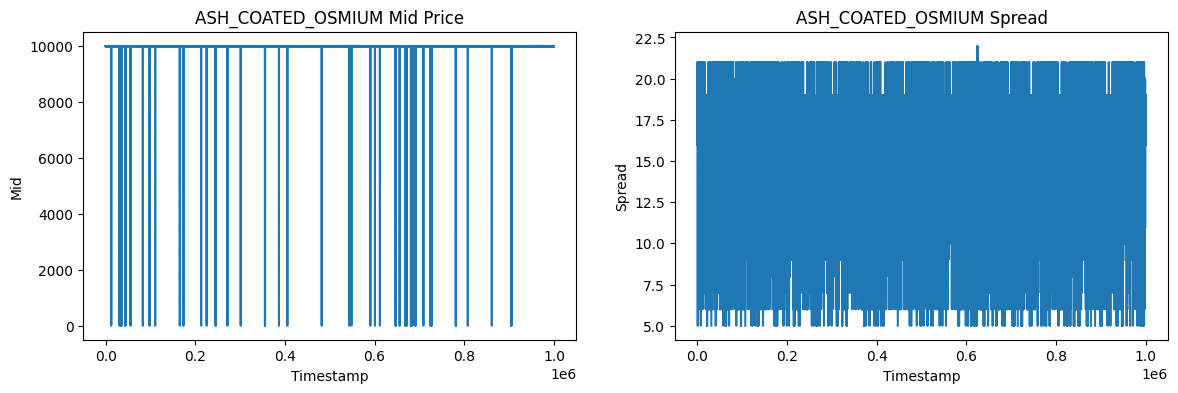

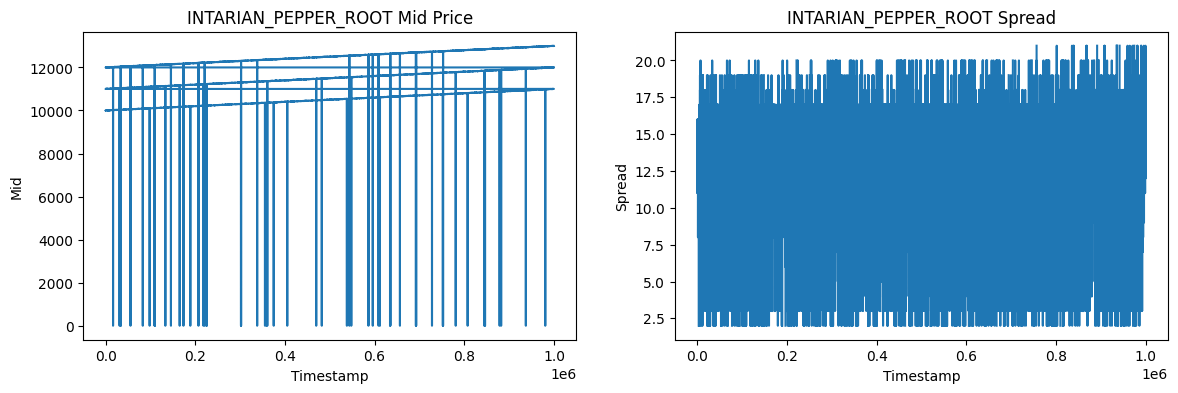

In [52]:
for product, df in price_by_product.items():
    fig, axes = plt.subplots(1, 2, figsize=(14,4))
    
    axes[0].plot(df["timestamp"], df["mid"])
    axes[0].set_title(f"{product} Mid Price")
    axes[0].set_xlabel("Timestamp")
    axes[0].set_ylabel("Mid")
    
    axes[1].plot(df["timestamp"], df["spread"])
    axes[1].set_title(f"{product} Spread")
    axes[1].set_xlabel("Timestamp")
    axes[1].set_ylabel("Spread")
    
    plt.show()


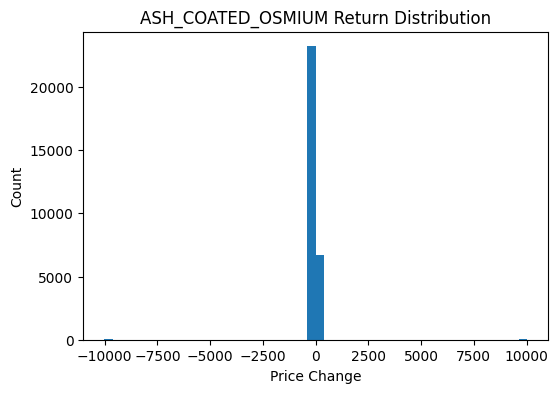

ASH_COATED_OSMIUM: lag1 autocorr = -0.5001, lag5 autocorr = 0.0000


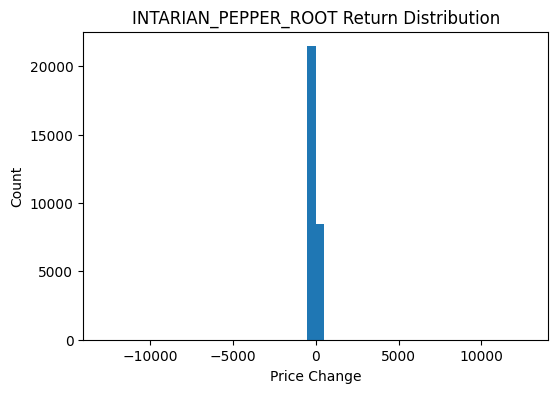

INTARIAN_PEPPER_ROOT: lag1 autocorr = -0.5001, lag5 autocorr = -0.0112


In [53]:
for product, df in price_by_product.items():
    plt.figure(figsize=(6,4))
    plt.hist(df["ret"].dropna(), bins=50)
    plt.title(f"{product} Return Distribution")
    plt.xlabel("Price Change")
    plt.ylabel("Count")
    plt.show()

    ac1 = df["ret"].autocorr(lag=1)
    ac5 = df["ret"].autocorr(lag=5)
    
    print(f"{product}: lag1 autocorr = {ac1:.4f}, lag5 autocorr = {ac5:.4f}")


### Purpose
- Run a lightweight diagnostic on whether each product looks flat, mean reverting, or trending.
- Prepare the notebook for the deeper product-specific sections that follow.

### Expected Result
- A stable rolling mean supports a more constant-value interpretation.
- A visibly moving rolling mean suggests drift, trend, or regime change.
- Strong short-horizon snapback would support mean reversion rather than random walk.

### Intuition
- A rolling mean is not a formal test, but it is a fast way to separate short-lived noise from slower structural movement.
- If the rolling mean itself moves materially, the product is unlikely to be truly constant.

### Steps
1. Overlay `mid` with a rolling mean for each product.
2. Compare the gap between short-run fluctuations and the slower baseline.
3. Use this as a bridge into the two product-specific diagnostics below.


# 4. Mean-Reversion vs Trending

A useful first check:

- If the product is nearly flat around one level, it may have a fixed fair value
- If it wanders but snaps back, it may be mean reverting
- If short-term returns have negative autocorrelation, market making may work well
- If returns have positive autocorrelation, momentum may exist


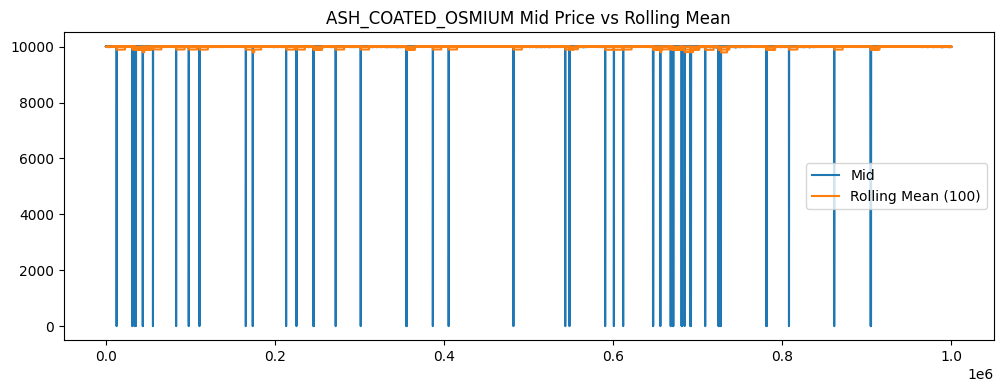

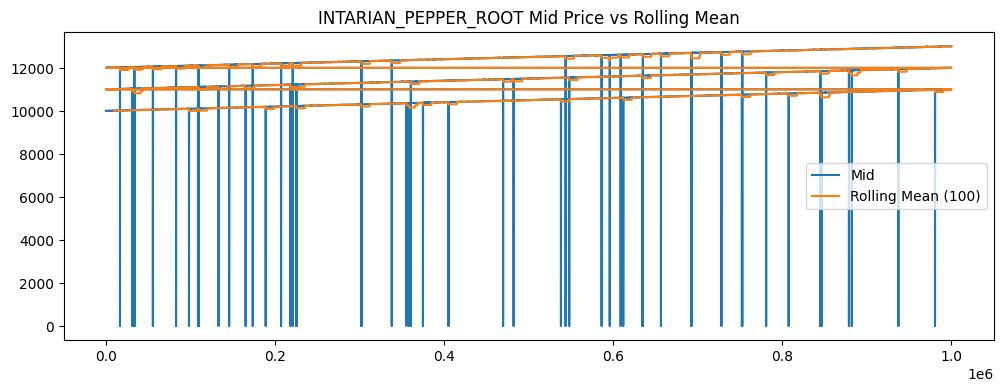

In [54]:
for product, df in price_by_product.items():
    rolling_mean = df["mid"].rolling(100).mean()
    
    plt.figure(figsize=(12,4))
    plt.plot(df["timestamp"], df["mid"], label="Mid")
    plt.plot(df["timestamp"], rolling_mean, label="Rolling Mean (100)")
    plt.title(f"{product} Mid Price vs Rolling Mean")
    plt.legend()
    plt.show()


# 5. `ASH_COATED_OSMIUM` Flat Price vs Random Walk

### Purpose
- Test whether `ASH_COATED_OSMIUM` behaves like a nearly flat price with a small random-walk component.
- Distinguish random walk from stable-noisy price action and weak mean reversion.

### Expected Result
- Stable rolling mean and narrow day-level ranges support a flat-price view.
- Diffusion-like noise with little pullback supports a random-walk view.
- Clear pullback after deviations and negative short-lag autocorrelation argue against random walk and in favor of mean reversion.

### Intuition
- A true random walk can drift away from its starting level without repeatedly snapping back to the same center.
- A flat product should keep revisiting a narrow value region and should not show persistent drift in its rolling mean.

### Steps
1. Plot `mid` using the full sample and split by `day`.
2. Plot returns and inspect their shape.
3. Compute multi-lag autocorrelation.
4. Compare rolling mean and rolling standard deviation over time.
5. Summarize day-level mean, standard deviation, and range.
6. Write down whether the evidence supports flatness, random walk, or mean reversion.


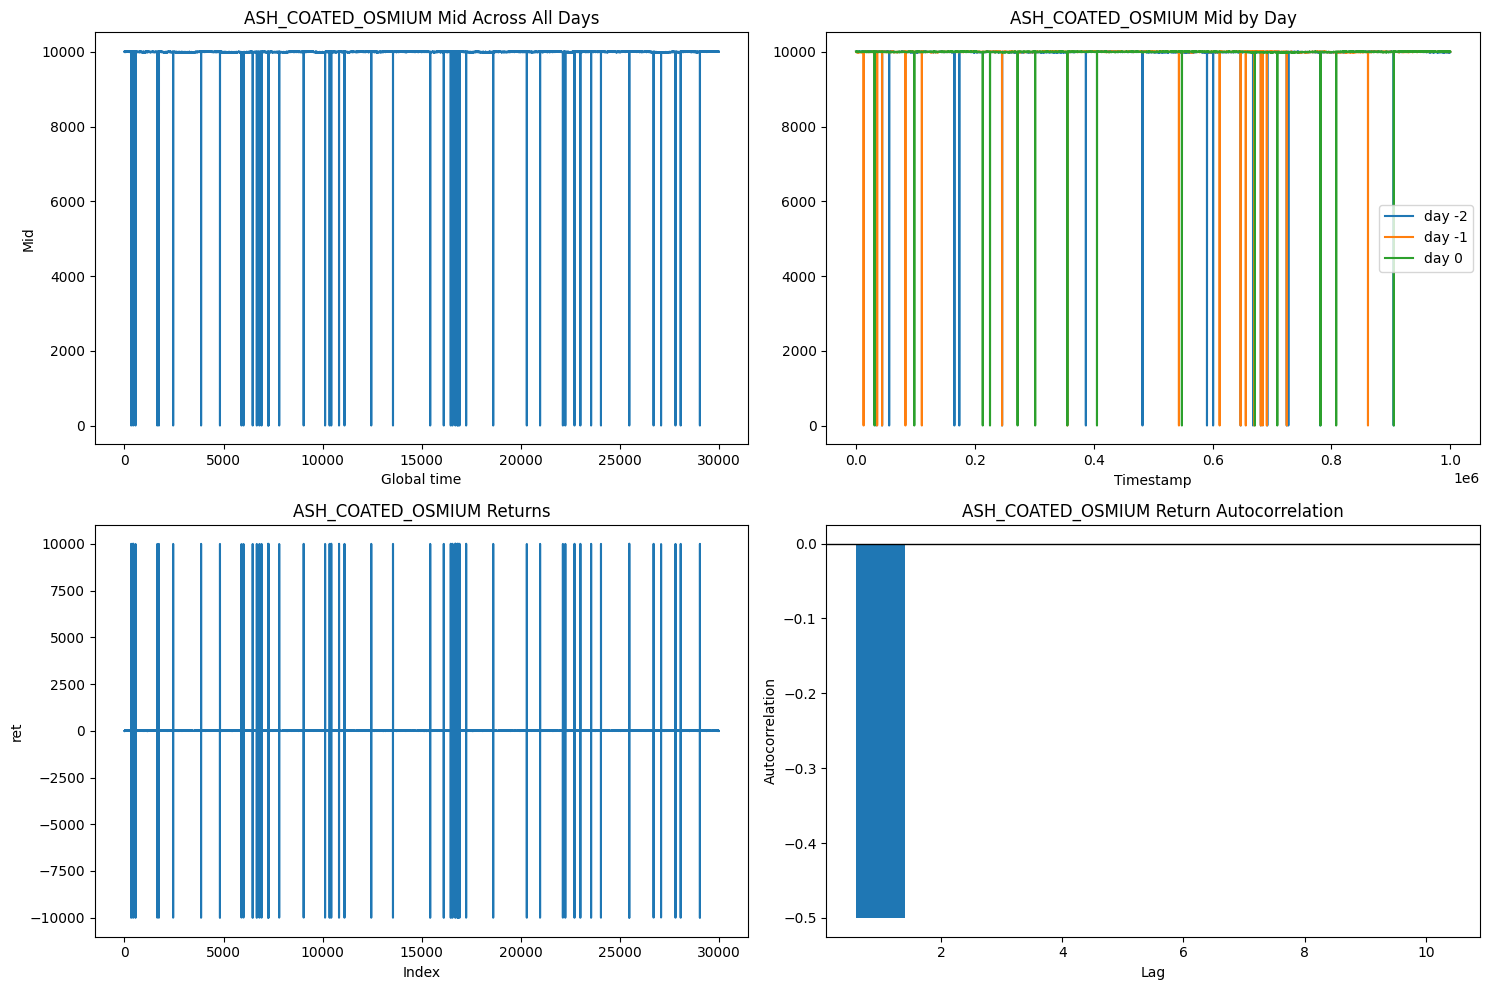

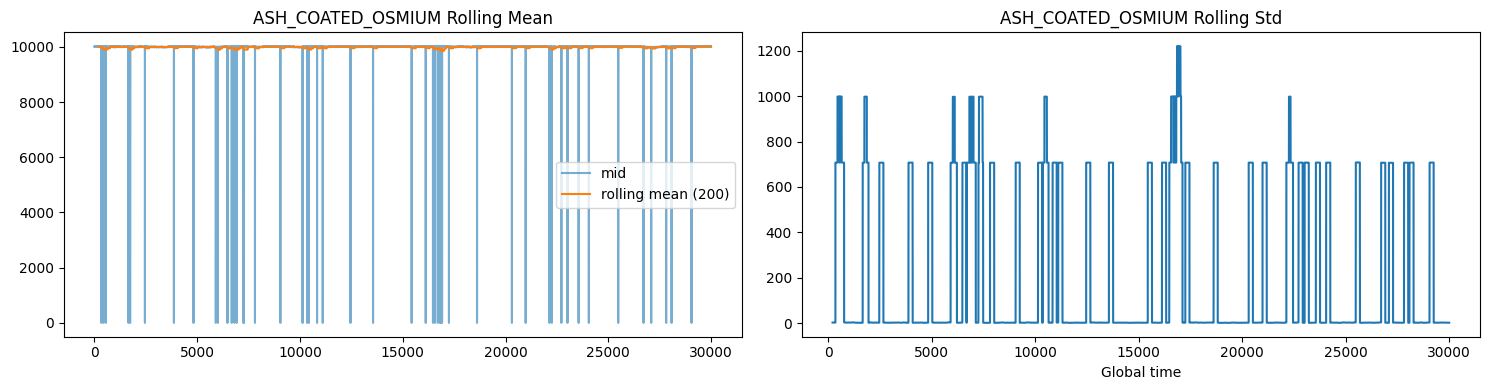

ASH_COATED_OSMIUM day summary
      mid_mean   mid_std  mid_min  mid_max  mid_range
day                                                  
-2   9980.1732  423.8578      0.0  10019.0    10019.0
-1   9983.8325  412.0389      0.0  10019.0    10019.0
 0   9987.6059  374.0257      0.0  10023.0    10023.0

ASH_COATED_OSMIUM return autocorrelation
1    -0.5001
2     0.0001
3    -0.0000
4     0.0000
5     0.0000
6    -0.0000
7    -0.0000
8    -0.0000
9     0.0000
10   -0.0000
dtype: float64

Overall mean/std/range
mean     9983.870567
std       403.865355
min         0.000000
max     10023.000000
Name: mid, dtype: float64


In [55]:
# ASH_COATED_OSMIUM diagnostic code
osmium = price_by_product["ASH_COATED_OSMIUM"].copy()
osmium_ret = osmium["ret"].dropna()
lag_autocorr = {lag: osmium_ret.autocorr(lag=lag) for lag in range(1, 11)}
day_summary = (
    osmium.groupby("day")
    .agg(mid_mean=("mid", "mean"), mid_std=("mid", "std"), mid_min=("mid", "min"), mid_max=("mid", "max"))
)
day_summary["mid_range"] = day_summary["mid_max"] - day_summary["mid_min"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].plot(osmium["global_time"], osmium["mid"])
axes[0, 0].set_title("ASH_COATED_OSMIUM Mid Across All Days")
axes[0, 0].set_xlabel("Global time")
axes[0, 0].set_ylabel("Mid")

for day, sub in osmium.groupby("day"):
    axes[0, 1].plot(sub["timestamp"], sub["mid"], label=f"day {day}")
axes[0, 1].set_title("ASH_COATED_OSMIUM Mid by Day")
axes[0, 1].set_xlabel("Timestamp")
axes[0, 1].legend()

axes[1, 0].plot(osmium_ret.index, osmium_ret.values)
axes[1, 0].set_title("ASH_COATED_OSMIUM Returns")
axes[1, 0].set_xlabel("Index")
axes[1, 0].set_ylabel("ret")

axes[1, 1].bar(list(lag_autocorr.keys()), list(lag_autocorr.values()))
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_title("ASH_COATED_OSMIUM Return Autocorrelation")
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

rolling_window = 200
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(osmium["global_time"], osmium["mid"], alpha=0.6, label="mid")
axes[0].plot(osmium["global_time"], osmium["mid"].rolling(rolling_window).mean(), label=f"rolling mean ({rolling_window})")
axes[0].set_title("ASH_COATED_OSMIUM Rolling Mean")
axes[0].legend()

axes[1].plot(osmium["global_time"], osmium["mid"].rolling(rolling_window).std())
axes[1].set_title("ASH_COATED_OSMIUM Rolling Std")
axes[1].set_xlabel("Global time")
plt.tight_layout()
plt.show()

print("ASH_COATED_OSMIUM day summary")
print(day_summary.round(4))
print("\nASH_COATED_OSMIUM return autocorrelation")
print(pd.Series(lag_autocorr).round(4))
print("\nOverall mean/std/range")
print(osmium["mid"].agg(["mean", "std", "min", "max"]))


### Interpretation
- If `ASH_COATED_OSMIUM` keeps revisiting a narrow center and the rolling mean stays fairly stable, that is evidence for a mostly flat product.
- If short-lag return autocorrelation is meaningfully negative, that is evidence against a pure random walk and more in favor of mean reversion or microstructure bounce.
- If day-level means are similar but day-level ranges stay narrow, the product is likely better described as stable with noise rather than as a drifting asset.
- Strategy intuition: flat-and-stable behavior is usually more compatible with market making than with long-horizon directional bets.


# 6. Large Order / Wall Price Analysis

### Purpose
- Compare ordinary mid with wall-based mid for each product.
- Check whether deeper visible liquidity carries extra information beyond the best bid and ask.

### Expected Result
- If wall-based mid closely tracks future price better than ordinary mid, it may contain predictive information.
- If wall-based mid behaves similarly to ordinary mid, it likely adds little incremental signal.

### Intuition
- The largest displayed size can act like a stronger reference level than the best quote alone.
- This matters most when one side of the book is thin or when large visible orders anchor short-term price movement.

### Steps
1. Identify the largest visible bid and ask levels.
2. Build a wall-based mid.
3. Compare wall mid against ordinary mid visually.
4. Use the comparison as a signal-screening step rather than a final proof.


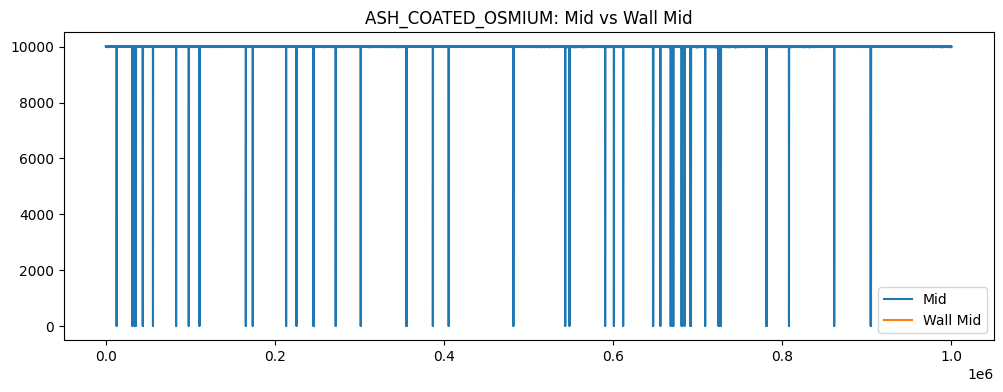

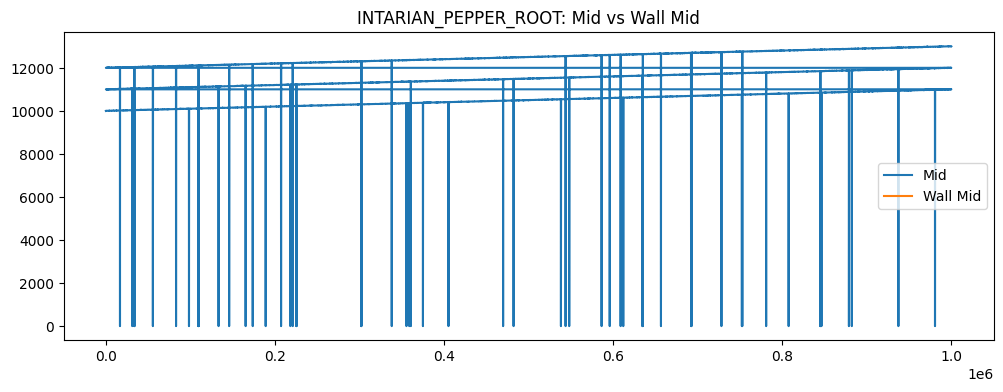

In [56]:
for product, df in price_by_product.items():
    bid_prices = [c for c in df.columns if "bid_price" in c]
    bid_sizes = [c for c in df.columns if "bid_volume" in c]
    ask_prices = [c for c in df.columns if "ask_price" in c]
    ask_sizes = [c for c in df.columns if "ask_volume" in c]

    if len(bid_prices) >= 3:
        def wall_bid(row):
            idx = np.argmax([row[v] for v in bid_sizes])
            return row[bid_prices[idx]]

        def wall_ask(row):
            idx = np.argmax([abs(row[v]) for v in ask_sizes])
            return row[ask_prices[idx]]

        df = df.copy()
        df["wall_bid"] = df.apply(wall_bid, axis=1)
        df["wall_ask"] = df.apply(wall_ask, axis=1)
        df["wall_mid"] = (df["wall_bid"] + df["wall_ask"]) / 2
        price_by_product[product] = df

        plt.figure(figsize=(12,4))
        plt.plot(df["timestamp"], df["mid"], label="Mid")
        plt.plot(df["timestamp"], df["wall_mid"], label="Wall Mid")
        plt.title(f"{product}: Mid vs Wall Mid")
        plt.legend()
        plt.show()


# 7. `INTARIAN_PEPPER_ROOT` Constant Value vs Slow Drift

### Purpose
- Test whether `INTARIAN_PEPPER_ROOT` is truly centered around a constant value.
- If not, determine whether the series looks like slow drift, a directional process, or a step-like regime change.

### Expected Result
- A nearly flat long-window baseline supports a constant-value interpretation.
- A persistently moving long-window baseline and non-zero time trend support a slow-changing process.
- Sharp jumps between levels support regime change more than smooth drift.

### Intuition
- A constant-value asset should not keep moving its long-run center over time.
- If the long-window mean shifts, then what looks noisy locally may still be part of a slower evolving price process.

### Steps
1. Plot the full-series `mid` together with a long-window rolling mean.
2. Split the plot by `day` to separate day-level movement from cross-day level changes.
3. Estimate a simple linear trend against time.
4. Compare the original series with de-trended residuals.
5. Inspect day-level means and step changes.
6. Decide whether the evidence points to constant value, slow drift, or regime change.


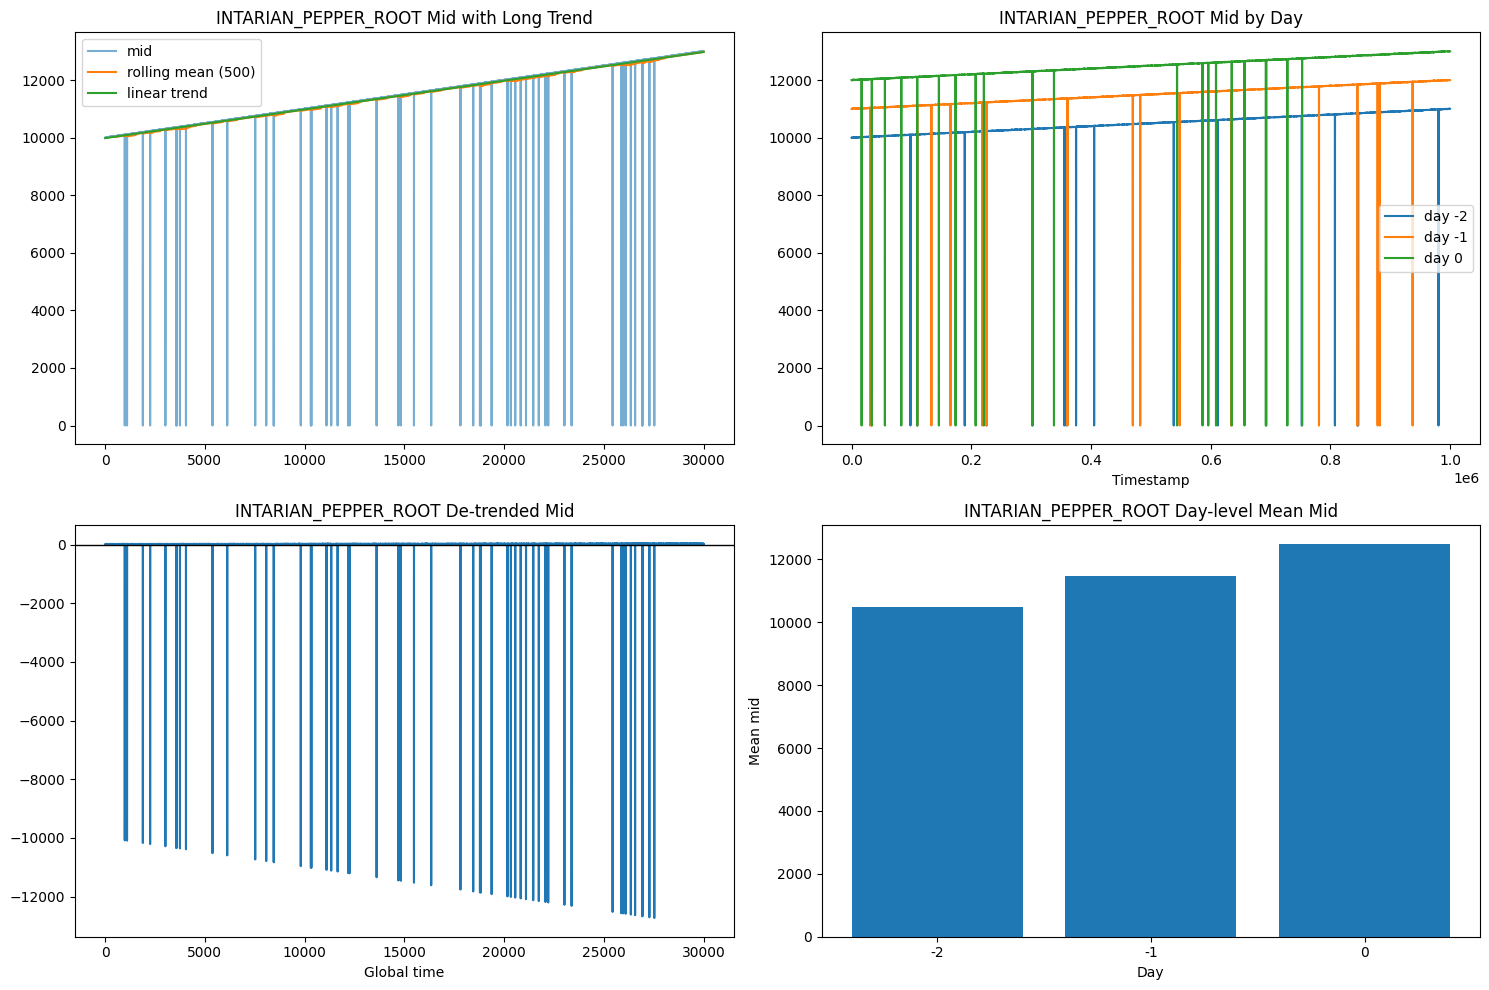

INTARIAN_PEPPER_ROOT linear trend slope/intercept
{'slope': np.float64(0.09974651976738416), 'intercept': np.float64(9983.040826749124)}

INTARIAN_PEPPER_ROOT day summary
       mid_mean   mid_std  mid_min  mid_max  mid_range
day                                                   
-2   10483.1636  509.2753      0.0  11003.0    11003.0
-1   11480.4800  554.6662      0.0  12006.0    12006.0
 0   12473.9226  640.8340      0.0  13007.0    13007.0

De-trended series summary
mean   -2.617404e-12
std     4.900904e+02
min    -1.272876e+04
max     3.505306e+01
Name: detrended_mid, dtype: float64


In [57]:
pepper = price_by_product["INTARIAN_PEPPER_ROOT"].copy()
trend_x = pepper["global_time"].to_numpy()
trend_y = pepper["mid"].to_numpy()
trend_coef = np.polyfit(trend_x, trend_y, 1)
pepper["trend_line"] = np.polyval(trend_coef, trend_x)
pepper["detrended_mid"] = pepper["mid"] - pepper["trend_line"]

pepper_day_summary = (
    pepper.groupby("day")
    .agg(mid_mean=("mid", "mean"), mid_std=("mid", "std"), mid_min=("mid", "min"), mid_max=("mid", "max"))
)
pepper_day_summary["mid_range"] = pepper_day_summary["mid_max"] - pepper_day_summary["mid_min"]

rolling_window = 500
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].plot(pepper["global_time"], pepper["mid"], alpha=0.6, label="mid")
axes[0, 0].plot(pepper["global_time"], pepper["mid"].rolling(rolling_window).mean(), label=f"rolling mean ({rolling_window})")
axes[0, 0].plot(pepper["global_time"], pepper["trend_line"], label="linear trend")
axes[0, 0].set_title("INTARIAN_PEPPER_ROOT Mid with Long Trend")
axes[0, 0].legend()

for day, sub in pepper.groupby("day"):
    axes[0, 1].plot(sub["timestamp"], sub["mid"], label=f"day {day}")
axes[0, 1].set_title("INTARIAN_PEPPER_ROOT Mid by Day")
axes[0, 1].set_xlabel("Timestamp")
axes[0, 1].legend()

axes[1, 0].plot(pepper["global_time"], pepper["detrended_mid"])
axes[1, 0].axhline(0, color="black", linewidth=1)
axes[1, 0].set_title("INTARIAN_PEPPER_ROOT De-trended Mid")
axes[1, 0].set_xlabel("Global time")

axes[1, 1].bar(pepper_day_summary.index.astype(str), pepper_day_summary["mid_mean"])
axes[1, 1].set_title("INTARIAN_PEPPER_ROOT Day-level Mean Mid")
axes[1, 1].set_xlabel("Day")
axes[1, 1].set_ylabel("Mean mid")
plt.tight_layout()
plt.show()

print("INTARIAN_PEPPER_ROOT linear trend slope/intercept")
print({"slope": trend_coef[0], "intercept": trend_coef[1]})
print("\nINTARIAN_PEPPER_ROOT day summary")
print(pepper_day_summary.round(4))
print("\nDe-trended series summary")
print(pepper["detrended_mid"].agg(["mean", "std", "min", "max"]))


### Interpretation
- If the long rolling mean and fitted trend both move over time, that is strong evidence against a truly constant value.
- If the de-trended series looks much more stable than the raw series, then a slow-moving baseline is likely part of the price process.
- If day-level means differ sharply, that suggests the process may include regime shifts or level resets in addition to within-day noise.
- Strategy intuition: a slow-changing baseline weakens naive constant-fair-value market making and suggests adapting quotes to the evolving level.


### Purpose
- Compare ordinary mid with wall-based mid for each product.
- Check whether deeper visible liquidity carries extra information beyond the best bid and ask.

### Expected Result
- If wall-based mid closely tracks future price better than ordinary mid, it may contain predictive information.
- If wall-based mid behaves similarly to ordinary mid, it likely adds little incremental signal.

### Intuition
- The largest displayed size can act like a stronger reference level than the best quote alone.
- This matters most when one side of the book is thin or when large visible orders anchor short-term price movement.

### Steps
1. Identify the largest visible bid and ask levels.
2. Build a wall-based mid.
3. Compare wall mid against ordinary mid visually.
4. Use the comparison as a signal-screening step rather than a final proof.


# 6. Trade Data Analysis

We now analyze trade data for both `INTARIAN_PEPPER_ROOT` and `ASH_COATED_OSMIUM`.

The goal is to inspect:
- who is trading,
- how much volume prints in each product,
- whether trades tend to happen above or below the quoted mid,
- and whether bursts of trading line up with price moves.


   timestamp  buyer  seller                symbol currency    price  quantity
0        700    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9990.0         6
1        900    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9998.0         2
2       1000    NaN     NaN  INTARIAN_PEPPER_ROOT   XIRECS   9995.0         7
3       2500    NaN     NaN     ASH_COATED_OSMIUM   XIRECS  10011.0         8
4       4000    NaN     NaN  INTARIAN_PEPPER_ROOT   XIRECS  10007.0         7

=== INTARIAN_PEPPER_ROOT ===
trades: 3033
total quantity: 15690
avg trade price: 11495.9416
avg quoted mid: 11493.7517
avg trade-mid: 2.1899
avg absolute trade-mid: 905.6149


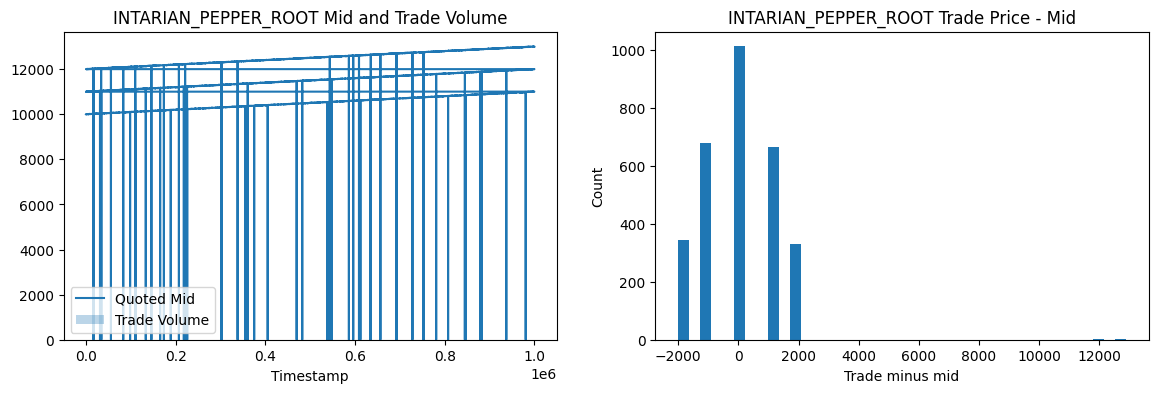

Top buyers:
buyer
UNKNOWN    3033
Name: count, dtype: int64
Top sellers:
seller
UNKNOWN    3033
Name: count, dtype: int64
Correlation between timestamp-level volume and avg trade-mid:
                 quantity  trade_minus_mid
quantity         1.000000         0.046619
trade_minus_mid  0.046619         1.000000

=== ASH_COATED_OSMIUM ===
trades: 3795
total quantity: 19779
avg trade price: 10000.2134
avg quoted mid: 9994.8909
avg trade-mid: 5.3225
avg absolute trade-mid: 14.0951


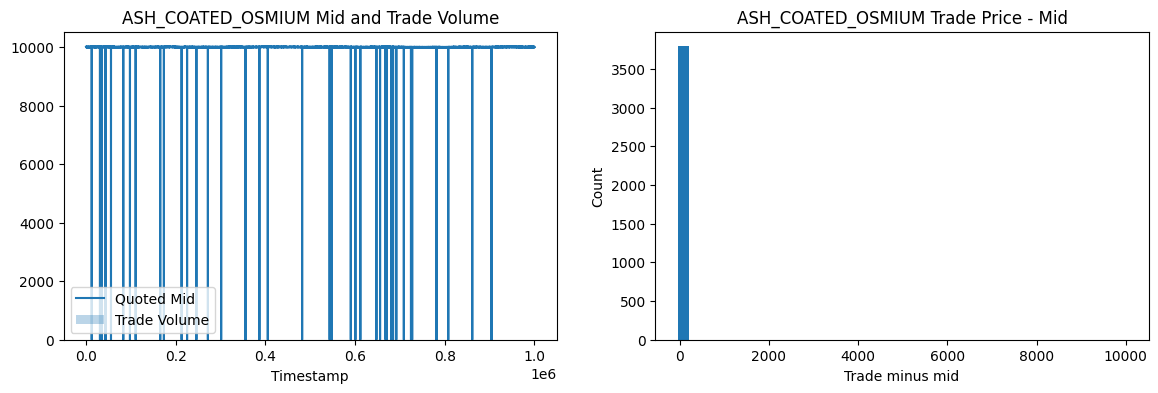

Top buyers:
buyer
UNKNOWN    3795
Name: count, dtype: int64
Top sellers:
seller
UNKNOWN    3795
Name: count, dtype: int64
Correlation between timestamp-level volume and avg trade-mid:
                 quantity  trade_minus_mid
quantity         1.000000        -0.023519
trade_minus_mid -0.023519         1.000000


In [58]:
print(trades.head())
PRODUCTS = ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"]

for product in PRODUCTS:
    trade_df = trade_by_product[product].copy()
    price_df = price_by_product[product][["timestamp", "mid", "spread"]].copy()

    merged = trade_df.merge(price_df, on="timestamp", how="left")
    merged["notional"] = merged["price"] * merged["quantity"]
    merged["trade_minus_mid"] = merged["price"] - merged["mid"]
    merged["trade_minus_mid_bps"] = 10000 * merged["trade_minus_mid"] / merged["mid"]

    print(f"\n=== {product} ===")
    print("trades:", len(merged))
    print("total quantity:", merged["quantity"].sum())
    print("avg trade price:", round(merged["price"].mean(), 4))
    print("avg quoted mid:", round(merged["mid"].mean(), 4))
    print("avg trade-mid:", round(merged["trade_minus_mid"].mean(), 4))
    print("avg absolute trade-mid:", round(merged["trade_minus_mid"].abs().mean(), 4))

    volume_by_time = merged.groupby("timestamp", as_index=False)["quantity"].sum()
    signed_price = merged.groupby("timestamp", as_index=False)["trade_minus_mid"].mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(price_df["timestamp"], price_df["mid"], label="Quoted Mid")
    axes[0].bar(volume_by_time["timestamp"], volume_by_time["quantity"], alpha=0.3, label="Trade Volume")
    axes[0].set_title(f"{product} Mid and Trade Volume")
    axes[0].set_xlabel("Timestamp")
    axes[0].legend()

    axes[1].hist(merged["trade_minus_mid"].dropna(), bins=40)
    axes[1].set_title(f"{product} Trade Price - Mid")
    axes[1].set_xlabel("Trade minus mid")
    axes[1].set_ylabel("Count")
    plt.show()

    if "buyer" in merged.columns:
        buyer_counts = merged["buyer"].fillna("UNKNOWN").value_counts().head()
        seller_counts = merged["seller"].fillna("UNKNOWN").value_counts().head()
        print("Top buyers:")
        print(buyer_counts)
        print("Top sellers:")
        print(seller_counts)

    print("Correlation between timestamp-level volume and avg trade-mid:")
    joined = volume_by_time.merge(signed_price, on="timestamp", how="inner")
    print(joined[["quantity", "trade_minus_mid"]].corr())



=== Price/Trade Linkage: INTARIAN_PEPPER_ROOT ===
                trade_count  total_quantity       ret  next_ret    spread
trade_count        1.000000        0.958350  0.005354 -0.003234 -0.115236
total_quantity     0.958350        1.000000  0.003683 -0.002947 -0.118009
ret                0.005354        0.003683  1.000000 -0.500051  0.006210
next_ret          -0.003234       -0.002947 -0.500051  1.000000  0.005290
spread            -0.115236       -0.118009  0.006210  0.005290  1.000000


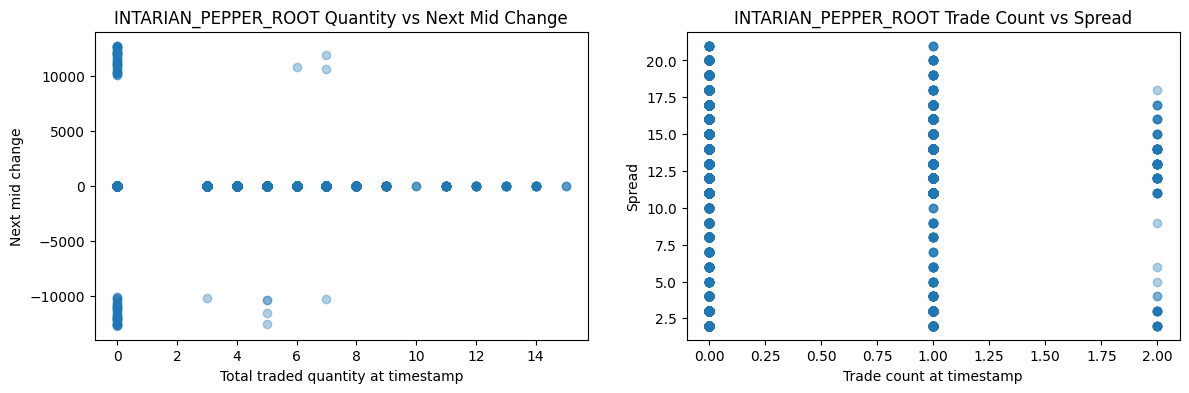


=== Price/Trade Linkage: ASH_COATED_OSMIUM ===
                trade_count  total_quantity       ret  next_ret    spread
trade_count        1.000000        0.917210  0.008249 -0.003271 -0.000778
total_quantity     0.917210        1.000000  0.008102 -0.003753  0.004961
ret                0.008249        0.008102  1.000000 -0.500076  0.001902
next_ret          -0.003271       -0.003753 -0.500076  1.000000  0.003565
spread            -0.000778        0.004961  0.001902  0.003565  1.000000


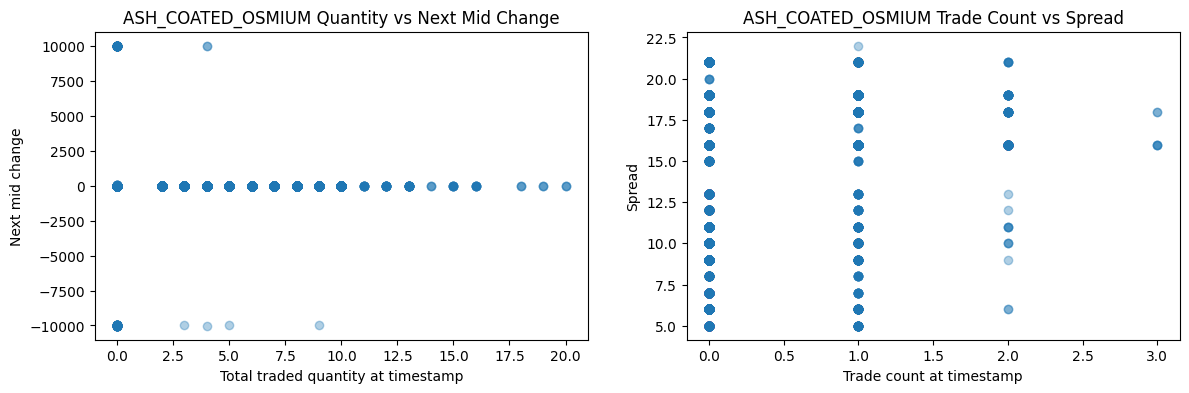

In [59]:
# Price + trade linkage: does heavier trading line up with the next move?
for product in PRODUCTS:
    price_df = price_by_product[product][["timestamp", "mid", "ret", "spread"]].copy()
    trade_df = trade_by_product[product].copy()

    trade_summary = (
        trade_df.groupby("timestamp", as_index=False)
        .agg(trade_count=("price", "size"), total_quantity=("quantity", "sum"), avg_trade_price=("price", "mean"))
    )

    joined = price_df.merge(trade_summary, on="timestamp", how="left").fillna({
        "trade_count": 0,
        "total_quantity": 0,
    })
    joined["next_ret"] = joined["mid"].shift(-1) - joined["mid"]
    joined["trade_count"] = joined["trade_count"].astype(int)

    print(f"\n=== Price/Trade Linkage: {product} ===")
    print(joined[["trade_count", "total_quantity", "ret", "next_ret", "spread"]].corr())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].scatter(joined["total_quantity"], joined["next_ret"], alpha=0.35)
    axes[0].set_title(f"{product} Quantity vs Next Mid Change")
    axes[0].set_xlabel("Total traded quantity at timestamp")
    axes[0].set_ylabel("Next mid change")

    axes[1].scatter(joined["trade_count"], joined["spread"], alpha=0.35)
    axes[1].set_title(f"{product} Trade Count vs Spread")
    axes[1].set_xlabel("Trade count at timestamp")
    axes[1].set_ylabel("Spread")
    plt.show()


# 7. Initial Conclusions Template

### Purpose
- Summarize the evidence from all prior sections into direct answers to the two main research questions.
- Turn plots and summary statistics into a usable trading interpretation.

### Expected Result
- The final write-up should clearly state which hypothesis is most supported for each product.
- The conclusion should refer back to specific diagnostics rather than relying on intuition alone.

### Intuition
- A good notebook should end by answering the original questions explicitly.
- The conclusion becomes much stronger when each claim is tied to an earlier section of evidence.

### Steps
1. State the best-supported description for `ASH_COATED_OSMIUM`.
2. State the best-supported description for `INTARIAN_PEPPER_ROOT`.
3. Reference the sections that support each conclusion.
4. Translate the findings into strategy implications.

## `ASH_COATED_OSMIUM`
- Does the price stay near a stable center across all three days?
- Do the rolling mean and day-level summary support a mostly flat process?
- Do the return autocorrelations support random walk, or do they look more mean reverting?
- Is this product better described as flat-with-noise, random walk, or weak mean reversion?
- What kind of strategy does that suggest?

## `INTARIAN_PEPPER_ROOT`
- Does the price behave like a constant fair value, or does its baseline move over time?
- Do the long rolling mean and fitted time trend support a slow-changing process?
- Are the changes smooth, or do they look more like step changes across days or subperiods?
- After de-trending, does the residual series look much more stable?
- What kind of strategy does that suggest?
